In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import deepRD.tools.trajectoryTools as trajectoryTools
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [118]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(128,128)):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU(), nn.LayerNorm(h)]
            d = h
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def reparam(mu, logvar):
    eps = torch.randn_like(mu)
    return mu + eps * torch.exp(0.5 * logvar)

def softplus_floor(x, floor):
    # smooth lower bound: >= floor, with gradient
    return floor + F.softplus(x - floor)  # log(1 + exp(x - floor)) + floor

def sigmoid_box(x, lo, hi, temp=1.0):
    return lo + (hi - lo) * torch.sigmoid(temp * x)

class DiagGaussianHead(nn.Module):
    """Outputs (mu, log_sigma) for R^3."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.mlp = MLP(in_dim, out_dim, hidden=(128,128))
    def forward(self, x):
        out = self.mlp(x)
        mu, log_sig = out[..., :3], out[..., 3:]
        return mu, log_sig

# ---------- CVAE ----------
class CVAE(nn.Module):
    def __init__(self, idim=3, cdim=6, zdim=3, zdrop=0.15):
        super().__init__()
        self.cdim, self.zdim, self.zdrop = cdim, zdim, zdrop
        self.encoder = MLP(idim + cdim, out_dim=2*zdim, hidden=(128,128))
        self.prior   = MLP(cdim, out_dim=3*zdim, hidden=(160,160))
        self.decoder = DiagGaussianHead(zdim + cdim, 2*idim)
        
        self.z_prev = None
        self.df = nn.Parameter(torch.tensor(6.0))
        
    def attach_normalizers(self, scaler_v, scaler_r):
        """Attach normalization scalers for automatic preprocessing."""
        self.scaler_v = scaler_v
        self.scaler_r = scaler_r

    def encode(self, r_next, c):
        """ q(z|x,c) → μ_q, logσ²_q """
        q = self.encoder(torch.cat([r_next, c], dim=-1))
        q_mu, q_logv = q.split(self.zdim, dim=-1)
        return q_mu, q_logv

    def prior_params(self, c):
        """ p(z|c) → μ_p, logσ²_p, ρ (0<rho<1) """
        p = self.prior(c)
        p_mu, p_logv, raw_rho = p.split(self.zdim, dim=-1)
        
        p_logv = torch.clamp(p_logv, -1.8, 1.5)

        
        rho_min, rho_max, temp = 0.05, 0.9, 1.0
        rho = sigmoid_box(raw_rho, rho_min, rho_max, temp)  # (rho_min, rho_max)
        return p_mu, p_logv, rho

    def decode(self, z, c, p_cdrop=0.05):
        """ p(x|z,c) → μ_r, logσ²_r """
        
        if self.training and self.zdrop > 0:
            dropmask = (torch.rand_like(z) > self.zdrop).float()
            z = z * dropmask
        if self.training and p_cdrop>0:
            mask = (torch.rand_like(c) > p_cdrop).float()
            c = c * mask
            
        #mu, log_sig = self.decoder(torch.cat([z, c], dim=-1))
        #log_sig = torch.clamp(log_sig, min=-2.5, max=1.5)
        mu, raw_logsig = self.decoder(torch.cat([z, c], dim=-1))
        log_sig = softplus_floor(raw_logsig, floor=-1.4)  # try -1.5 first (σ_min ≈ 0.223)

        # homoscedastic noise so spikes can’t form
        #if not hasattr(self, "log_sigma_global"):
        #    self.log_sigma_global = nn.Parameter(torch.tensor(-2.0))   # σ0 ≈ 0.135
        #sigma_pred = torch.exp(log_sig)
        #sigma0     = torch.exp(self.log_sigma_global)
        #sigma_eff  = torch.sqrt(sigma_pred*sigma_pred + sigma0*sigma0)
        #log_sig    = torch.log(sigma_eff)

        return mu, log_sig, raw_logsig

    def forward(self, r_next, c, r_next_prev, c_prev, is_new_seq):
        
        """
        Forward pass of the conditional VAE with autoregressive prior.

        Args:
            r_next (Tensor): Target variable at the current step.
            c (Tensor): Conditioning variables (e.g., velocity, auxiliary state) at the current step.
            
            r_next_prev (Tensor): Target variable from the previous step (for teacher forcing).
            c_prev (Tensor): Conditioning variables from the previous step.
            
            is_new_seq (Tensor): Binary mask (0/1) indicating sequence boundaries 
                                 (1 for the start of a new sequence).

        Returns:
            dec_out (Tensor): Decoder output (reconstruction of r_next).
            (q_mu, q_logv) (Tuple[Tensor, Tensor]): Mean and log-variance of the posterior q(z|r_next, c).
            (ar_mu, p_logv) (Tuple[Tensor, Tensor]): Mean and log-variance of the autoregressive prior p(z_t|z_{t-1}, c).
            rho_eff (Tensor): Effective autoregressive coefficient
        """
        
        # current posterior
        q_mu, q_logv = self.encode(r_next, c)
        z_q = reparam(q_mu, q_logv)
        
        # prior (μ_p, σ_p, ρ) at current step
        p_mu, p_logv, rho = self.prior_params(c)
        
        # previous latent from previous step (teacher forcing)
        prev_q_mu, prev_q_logv = self.encode(r_next_prev, c_prev)
        z_prev = prev_q_mu.detach()
        
        #zero-out AR link at sequence starts
        if is_new_seq.dim() == 1:
            is_new_seq = is_new_seq.unsqueeze(-1)
        rho_eff = rho * (1.0 - is_new_seq)  # 0 at start; rho elsewhere
        
        # AR(1) prior mean
        ar_mu = rho_eff*z_prev + (1.0-rho_eff)*p_mu
        
        dec_out = self.decode(z_q, c)
        return dec_out, (q_mu, q_logv), (ar_mu, p_logv), rho_eff

    def reset_latent_state(self, batch_size=1):
        """Call at the start of a new simulation trajectory"""
        self.z_prev = torch.zeros(batch_size, self.zdim, device=device)

    @torch.no_grad()
    def sample_torch(self, c, Tz=1.0, Tr=1.0):
        """
        Sampling from torch tensor, no (de)normalisation.
        """
        if self.z_prev is None:
            self.reset_latent_state(batch_size=c.shape[0])
            
        p_mu, p_logv, rho = self.prior_params(c)
        #z = reparam(p_mu, p_logv)  # sample from p(z|c)
        z = rho * self.z_prev + (1 - rho) * p_mu + torch.exp(0.5 * p_logv) * torch.randn_like(p_mu) * Tz
        self.z_prev = z.detach()
        
        mu, log_sig, _ = self.decode(z, c)
        r = mu + torch.exp(log_sig) * torch.randn_like(mu) * Tr
        return r
    
    @torch.no_grad()
    def sample(self, c_n_np, Tr=1.0, Tz=1.0, device=device):
        """
        Sample r_{n+1} in physical units given c = [v_n, r_n] as NumPy array. 
        Built in normalisation of input and denormalisation of output.

        Args:
            c_n_np (np.ndarray): shape (..., 6)
            Tr (float): temperature scaling factor for stochasticity at output of decoder
            Tz (float): temperature scaling for latent space sample
            device (torch.device): GPU/CPU device to use (optional)

        Returns:
            np.ndarray: generated r_{n+1} in same physical scale as input
        """
        if device is None:
            device = next(self.parameters()).device

        # --- Normalize inputs ---
        v_n_np, r_n_np = c_n_np[...,:3], c_n_np[..., 3:]
        
        single_sample = False
        if r_n_np.ndim == 1:
            r_n_np = r_n_np.reshape(1, -1)
            v_n_np = v_n_np.reshape(1, -1)
            single_sample = True
        
        v_norm = self.scaler_v.transform(v_n_np)
        r_norm = self.scaler_r.transform(r_n_np)
        c = np.concatenate([v_norm, r_norm], axis=-1)
        
        if self.z_prev is None:
            self.reset_latent_state(batch_size=c.shape[0])

        # --- Convert to torch tensor ---
        c_t = torch.tensor(c, dtype=torch.float32, device=device)

        # --- Sample from conditional prior and decode ---
        r_next_norm_t = self.sample_torch(c_t, Tr=Tr, Tz=Tz)
        
        # --- De-normalize to physical scale ---
        r_next_np = r_next_norm_t.cpu().numpy()
        r_next_phys = self.scaler_r.inverse_transform(r_next_np)
        
        if single_sample:
            r_next_phys = r_next_phys.squeeze()  # (3,)

        return r_next_phys

In [54]:
def gaussian_nll_diag(x, mu, log_sig):
    # x, mu, log_sig: [..., 3]
    # Sum over dims; mean over batch
    return 0.5 * ((x - mu)**2 * torch.exp(-2*log_sig) + 2*log_sig + torch.log(torch.tensor(2*math.pi, device=x.device))).sum(-1).mean()

def student_t_nll(x, mu, log_s, df):
    # x, mu, log_s: [B,3]; df: scalar (>2)
    s2 = torch.exp(2*log_s)
    z  = (x - mu)**2 / s2
    d  = df
    # per-dim NLL, then sum over dims and mean over batch
    nll = 0.5*(torch.log(s2)) + 0.5*(d+1)*torch.log1p(z/d)
    # add constant term (ok to drop for training, include if you want exact NLL):
    # nll += 0.5*(torch.log(torch.tensor(math.pi*d))) + torch.lgamma((d+1)/2)-torch.lgamma(d/2)
    return nll.sum(-1).mean()


def kl_diag(q_mu, q_logv, p_mu, p_logv):
    # all [..., zdim]
    # KL(q||p) for diagonal Gaussians; mean over batch
    return 0.5 * (torch.exp(q_logv - p_logv) + (q_mu - p_mu)**2 * torch.exp(-p_logv) - 1 + p_logv - q_logv).sum(-1).mean()

def kl_free_bits(mu_q, logv_q, mu_p, logv_p, free_bits=0.5):
    kl_el = 0.5 * (
        torch.exp(logv_q - logv_p)
        + (mu_q - mu_p)**2 * torch.exp(-logv_p)
        - 1 + logv_p - logv_q
    )  # [B, zdim]
    kl_el = torch.clamp(kl_el, min=free_bits)
    return kl_el.sum(dim=-1).mean()

def free_bits_lambda(epoch, warm=30, decay_to=0.05, start=0.5, total=80):
    if epoch <= warm:
        return start - (start-0.2) * (epoch/warm)
    # decay further to decay_to
    t = min(1.0, (epoch - warm) / (total - warm))
    return 0.2 - (0.2 - decay_to) * t

def elbo_loss(r_next, dec_out, q, p, beta=1.0, full_cov=False):
    q_mu, q_logv = q
    p_mu, p_logv = p

    mu, log_sig = dec_out
    nll = gaussian_nll_diag(r_next, mu, log_sig)
    kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
    return nll + beta * kl, nll, kl

In [55]:
def train_cvae(model, train_loader, val_loader=None,
                epochs=50, lr=1e-3, beta_max=1.0, warmup_epochs=10, 
                grad_clip=1.0, save_path=None):

    # Loss history
    train_total, train_nll, train_kl = [], [], []
    val_total = []

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler()  # mixed precision
    
    for epoch in range(1, epochs+1):
        
        # ---- KL warm-up ----
        beta = beta_max * min(1.0, epoch/warmup_epochs)
            
        model.train()
        total_loss, total_nll, total_kl = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        for batch in loop:
            # Batch: (r_{n+1}, c, r_prev, c_prev, is_new)
            r_next, c, r_next_prev, c_prev, is_new = [x.to(device) for x in batch]
            #c = torch.cat([v_n, r_n], dim=-1)  # conditioning variable
            
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                dec_out, q, p, rho = model(r_next, c, r_next_prev, c_prev, is_new)
                q_mu, q_logv = q
                #p_mu, p_logv = p
                ar_mu, p_logv = p
                mu_r, log_sig_r, raw_logsig = dec_out

                nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
                #nll = student_t_nll(r_next, mu_r, log_sig_r, model.df)
                
                fb = free_bits_lambda(epoch, warm=30, decay_to=0.05, start=0.5, total=80)
                #kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
                kl  = kl_diag(q_mu, q_logv, ar_mu, p_logv)
                #kl = kl_free_bits(q_mu, q_logv, ar_mu, p_logv, free_bits=fb)

                #mean_match = 1e-4 * (q_mu.detach() - ar_mu).pow(2).mean()
                #var_reg    = 1e-4 * (p_logv**2).mean()
                dec_var_reg = 1e-4 * (log_sig_r**2).mean()
                
                loss = nll + beta*kl #+ mean_match + var_reg
                #loss = nll + beta * kl

            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            total_nll += nll.item()
            total_kl += kl.item()

            loop.set_postfix(loss=loss.item(), NLL=nll.item(), KL=kl.item())

        scheduler.step()
        print(f"Epoch {epoch}: loss={total_loss/len(train_loader):.4f}, "
              f"NLL={total_nll/len(train_loader):.4f}, KL={total_kl/len(train_loader):.4f}")
        
        train_total.append(total_loss/len(train_loader))
        train_nll.append(total_nll/len(train_loader))
        train_kl.append(total_kl/len(train_loader))
        
        # ---- optional validation ----
        if val_loader is not None and epoch % 5 == 0:
            val_loss = evaluate_cvae(model, val_loader, beta)
            print(f"Validation loss: {val_loss:.4f}")
            val_total.append(val_loss)
            
        with torch.no_grad():
            # per-dim KL
            kl_el = 0.5*(torch.exp(q_logv-p_logv) + (q_mu-ar_mu)**2*torch.exp(-p_logv) -1 + p_logv - q_logv)
            print("KL per-dim:", kl_el.mean(0).cpu().numpy(), 'FB per-dim:', fb)
            print("rho mean/max:", rho.mean().item(), rho.max().item())
            # clamp hit rates
            print("prior σ floor hits:", (p_logv <= -1.5+1e-6).float().mean().item())
            print("dec σ floor hits:", (raw_logsig <= -1.5+1e-6).float().mean().item())
            
            # Convert log-variances to standard deviations
            dec_sigma = torch.exp(log_sig_r)            # [batch, 3]
            prior_sigma = torch.exp(0.5 * p_logv)       # [batch, zdim]

            # Batch means (averaged over both batch and dimensions)
            dec_sigma_mean = dec_sigma.mean().item()
            prior_sigma_mean = prior_sigma.mean().item()

            print(f"decoder_sigma_mean={dec_sigma_mean:.3f}, prior_sigma_mean={prior_sigma_mean:.3f}")


        if save_path:
            torch.save({'model_state': model.state_dict()}, save_path)
            
    return {
        "train_total": train_total,
        "train_nll": train_nll,
        "train_kl": train_kl,
        "val_total": val_total,
    }

In [21]:
@torch.no_grad()
def evaluate_cvae(model, loader, beta=1.0):
    model.eval()
    total = 0
    for batch in loader:
        r_next, c, r_next_prev, c_prev, is_new = [x.to(device) for x in batch]

        dec_out, q, p, _ = model(r_next, c, r_next_prev, c_prev, is_new)
        q_mu, q_logv = q
        ar_mu, p_logv = p
        mu_r, log_sig_r, _ = dec_out
        
        nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
        kl  = kl_diag(q_mu, q_logv, ar_mu, p_logv)
        total += (nll + beta*kl).item()
    return total / len(loader)

In [22]:
class RVDatasetAR1(Dataset):
    """
    Build (t-1, t) pairs per trajectory for AR(1) teacher forcing.
    v_trajs, r_trajs: lists of arrays with shape [T, 3] each.
    """
    def __init__(self, v_trajs, r_trajs, show_progress=True):
        assert len(v_trajs) == len(r_trajs)
        self.samples = []  # list of dicts for flexibility

        iterator = tqdm(range(len(v_trajs)), desc="Building RVDatasetAR1") if show_progress else range(len(v_trajs))
        for i in iterator:
            v = v_trajs[i]
            r = r_trajs[i]
            T = len(v)
            # we need t>=1 so that c_{t-1} exists; target is r_{t+1} so t<=T-2
            for t in range(1, T-1):
                #c_t = np.concatenate([v[t],   r[t]],   axis=-1)
                c_t = torch.cat([v[t], r[t]], dim=-1) # [6]
                c_p = torch.cat([v[t-1], r[t-1]], dim=-1) # [6]
                self.samples.append({
                    "r_next": r[t+1],  # [3]
                    "c":      c_t,      # [6]
                    "r_next_prev": r[t],     # [3]
                    "c_prev": c_p,      # [6]
                    "is_new": torch.tensor(1.0 if t == 1 else 0.0),
                })

        if show_progress:
            print(f"✔ Finished building dataset. Total samples: {len(self.samples)}")
            
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return (
            s["r_next"],
            s["c"],
            s["r_next_prev"],
            s["c_prev"],
            s["is_new"]
        )

In [29]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
conditionedOn = 'piri'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim
# for dimer, alternating between particle 1 and particle 2.

# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 200
train_split = 0.8

# Sample simulation files randomly
fnums = np.random.choice(2500, n_datasets, replace=False)
print(np.sort(fnums))
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)
        
n_timesteps = dataset.shape[1]

# Dataset - training data
dataset.shape, dataset.flatten(end_dim=1).shape, n_timesteps, dataset.dtype

[   3    7    8   11   20   26   40   41   85   86   92   98  107  123
  124  147  157  161  167  173  175  193  201  207  224  232  263  287
  293  303  311  323  337  341  347  352  374  411  412  418  430  435
  448  463  465  478  485  504  511  515  517  540  542  566  575  589
  592  597  605  607  617  635  643  652  701  737  750  781  790  804
  811  818  827  830  849  864  869  871  877  881  884  891  898  901
  904  967  990 1000 1002 1022 1034 1057 1058 1066 1072 1074 1078 1105
 1117 1120 1131 1187 1196 1198 1209 1210 1234 1249 1252 1254 1260 1265
 1266 1270 1279 1293 1295 1298 1311 1318 1355 1394 1395 1423 1432 1442
 1453 1458 1467 1469 1472 1492 1507 1511 1535 1540 1608 1620 1637 1652
 1658 1666 1677 1684 1690 1692 1693 1697 1701 1707 1719 1720 1755 1758
 1783 1791 1802 1815 1852 1856 1862 1867 1911 1913 1916 1926 1932 1949
 1968 1993 2005 2006 2016 2032 2038 2039 2066 2071 2088 2131 2141 2161
 2199 2243 2251 2288 2311 2322 2335 2336 2362 2370 2372 2374 2396 2412
 2416 

(torch.Size([200, 10000, 11]), torch.Size([2000000, 11]), 10000, torch.float32)

In [30]:
q = dataset[..., 1:4]   # position (not used now, but may be later)
v = dataset[..., 4:7]   # velocity
r = dataset[..., 8:11]  # auxiliary var

In [31]:
v_n = v.reshape(-1, 3)
r_n = r.reshape(-1, 3)
r_next = r[:, 1:-1, :].reshape(-1, 3)

r_next_val = r_next[int(0.8*len(r_next)):]

In [32]:
## Normalization

scaler_v = StandardScaler().fit(v_n)
scaler_r = StandardScaler().fit(r_n)

v_norm = torch.tensor(scaler_v.transform(v_n), dtype=torch.float32).reshape(n_datasets, n_timesteps, 3)
r_norm = torch.tensor(scaler_r.transform(r_n), dtype=torch.float32).reshape(n_datasets, n_timesteps, 3)

In [33]:
r_n.mean(), r_n.std(), v_n.mean(), v_n.std(), v_norm.mean(), v_norm.std(), r_norm.mean(), r_norm.std()

(tensor(1.9326e-05),
 tensor(0.0162),
 tensor(-0.0004),
 tensor(0.1423),
 tensor(0.),
 tensor(1.0000),
 tensor(-3.0518e-11),
 tensor(1.0000))

In [34]:
## Saving Scaler Params

joblib.dump(
    {
        "scaler_v": scaler_v,
        "scaler_r": scaler_r
    },
    "normalizers_ar.pkl"
)

['normalizers_ar.pkl']

In [35]:
N = len(r_norm)
split = int(0.8*N)

In [36]:
#train_ds = RVDataset(r_next_norm[:split], v_n_norm[:split], r_n_norm[:split])
#val_ds   = RVDataset(r_next_norm[split:], v_n_norm[split:], r_n_norm[split:])

train_ds = RVDatasetAR1(v_norm[:split], r_norm[:split])
val_ds = RVDatasetAR1(v_norm[split:], r_norm[split:])

Building RVDatasetAR1: 100%|████████████████████████████████████████████████████████████████████████████████████████| 160/160 [01:19<00:00,  2.02it/s]


✔ Finished building dataset. Total samples: 1599680


Building RVDatasetAR1: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:23<00:00,  1.69it/s]

✔ Finished building dataset. Total samples: 399920


In [37]:
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=4096, shuffle=False, num_workers=4)

model = CVAE().to(device)

In [38]:
load_from_checkpoint=False
if load_from_checkpoint:
    scalers = joblib.load("normalizers_ar.pkl")
    model.attach_normalizers(**scalers)
    ckpt = torch.load("cvae_ar_checkpoint.pt", map_location="cpu")
    model.load_state_dict(ckpt['model_state'])

In [44]:
losses = train_cvae(model,
                    train_loader,
                    val_loader=val_loader,
                    epochs=50,
                    lr=1e-3,
                    beta_max=1.5,
                    warmup_epochs=25,
                    grad_clip=1.0,
                    save_path="cvae_ar_checkpoint.pt")

/tmp/ipykernel_3001723/3368458196.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # mixed precision
Epoch 1/50:   0%|                                                                                                             | 0/391 [00:00<?, ?it/s]/tmp/ipykernel_3001723/3368458196.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/50: 100%|█████████████████████████████████████████████████████████████████| 391/391 [00:17<00:00, 22.59it/s, KL=4.86, NLL=-0.0123, loss=0.279]


Epoch 1: loss=0.6072, NLL=0.3568, KL=4.1730
KL per-dim: [1.5722829 1.689661  1.593825 ] FB per-dim: 0.49
rho mean/max: 0.3684224486351013 0.87890625
prior σ floor hits: 0.20848214626312256
dec σ floor hits: 0.8787202835083008
decoder_sigma_mean=0.335, prior_sigma_mean=0.822


Epoch 2/50: 100%|█████████████████████████████████████████████████████████████████| 391/391 [00:17<00:00, 22.73it/s, KL=3.92, NLL=-0.0982, loss=0.372]


Epoch 2: loss=0.4580, NLL=-0.0124, KL=3.9196
KL per-dim: [1.3290591 1.3487564 1.2418067] FB per-dim: 0.48
rho mean/max: 0.3742343783378601 0.89794921875
prior σ floor hits: 0.23005953431129456
dec σ floor hits: 0.8961309790611267
decoder_sigma_mean=0.320, prior_sigma_mean=0.783


Epoch 3/50: 100%|███████████████████████████████████████████████████████████████████| 391/391 [00:16<00:00, 23.35it/s, KL=3.35, NLL=0.112, loss=0.714]


...

Epoch 49/50: 100%|███████████████████████████████████████████████████████████████████| 391/391 [00:17<00:00, 22.75it/s, KL=0.111, NLL=1.34, loss=1.51]


Epoch 49: loss=1.5205, NLL=1.3406, KL=0.1200
KL per-dim: [0.04901753 0.02354038 0.03803575] FB per-dim: 0.14300000000000002
rho mean/max: 0.04998893290758133 0.050323486328125
prior σ floor hits: 0.0
dec σ floor hits: 0.6824405193328857
decoder_sigma_mean=0.447, prior_sigma_mean=0.931


Epoch 50/50: 100%|███████████████████████████████████████████████████████████████████| 391/391 [00:16<00:00, 23.41it/s, KL=0.121, NLL=1.34, loss=1.52]

Epoch 50: loss=1.5194, NLL=1.3396, KL=0.1198


Validation loss: 1.4398
KL per-dim: [0.05530922 0.0257078  0.04025452] FB per-dim: 0.14
rho mean/max: 0.04998898133635521 0.05010986328125
prior σ floor hits: 0.0
dec σ floor hits: 0.6699405312538147
decoder_sigma_mean=0.457, prior_sigma_mean=0.933


In [123]:
train_total_losses, train_nll_losses, train_kl_losses, val_total_losses = losses.values()

NameError: name 'losses' is not defined

In [124]:
epochs_range = range(1, len(train_total_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_total_losses, label='Train Total Loss')
plt.plot(epochs_range, train_nll_losses, label='Train NLL Loss', linestyle='--')
plt.plot(epochs_range, train_kl_losses, label='Train KL Loss', linestyle='--')

if len(val_total_losses) > 0:
    plt.plot(epochs_range[4::5], val_total_losses, 'x--', label='Validation Loss', linewidth=1)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'train_total_losses' is not defined

In [120]:
valModel = CVAE().to(device)

scalers = joblib.load("normalizers_ar.pkl")
valModel.attach_normalizers(**scalers)
ckpt = torch.load("cvae_ar_checkpoint.pt", map_location="cpu", weights_only=True)
valModel.load_state_dict(ckpt['model_state'])

<All keys matched successfully>

In [90]:
def dataset_to_arrays(dataset):
    r_next_list, c_list, r_next_prev_list, c_prev_list = [], [], [], []
    for i in range(len(dataset)):
        r_next, c, r_prev, c_prev, _ = dataset[i]
        r_next_list.append(r_next.numpy())
        c_list.append(c.numpy())
        r_next_prev_list.append(r_prev.numpy())
        c_prev_list.append(c_prev.numpy())
    return (
        np.stack(r_next_list),
        np.stack(c_list),
        np.stack(r_next_prev_list),
        np.stack(c_prev_list),
    )

def dataset_to_tensors(dataset, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    r_next_list, c_list, r_next_prev_list, c_prev_list = [], [], [], []
    for i in range(len(dataset)):
        r_next, c, r_next_prev, c_prev, _ = dataset[i]
        r_next_list.append(r_next)
        c_list.append(c)
        r_next_prev_list.append(r_next_prev)
        c_prev_list.append(c_prev)

    return (
        torch.stack(r_next_list).to(device),
        torch.stack(c_list).to(device),
        torch.stack(r_next_prev_list).to(device),
        torch.stack(c_prev_list).to(device),
    )

In [91]:
def plot_r_distributions(model, r_next, c_n, r_next_prev=None, c_prev=None,
                         n_samples=50000, device="cpu", Tr=1.0, Tz=1.0):
    """
    Compare benchmark, reconstructed, and generated distributions of r_{n+1}.

    Args:
        model: trained CVAE model with attached scalers (scaler_v, scaler_r)
        c_n (np.ndarray): conditioning vectors [v_n, r_n], shape [N, 6]
        r_next (np.ndarray): true target auxiliary variable, shape [N, 3]
        r_prev (np.ndarray, optional): r_{n}, shape [N, 3]; required for reconstruction
        c_prev (np.ndarray, optional): [v_{n-1}, r_{n-1}], shape [N, 6]; required for reconstruction
        n_samples: number of samples to draw for visualization
        device: torch device
        Tr, Tz: sampling temperatures for decoder and latent
    """
    model.eval()

    # --- Subsample for efficiency ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    if r_next_prev is not None:
        r_next_prev_s = r_next_prev[idx]
    if c_prev is not None:
        c_prev_s = c_prev[idx]

    # INPUT DATA IS ALREADY NORMALISED

    # --- Reconstruction (using true previous step) ---
    if r_next_prev is not None and c_prev is not None:
        is_new_seq = torch.zeros(len(c_s), 1, device=device)

        with torch.no_grad():
            (mu_r, log_sig_r, _), _, _, _ = model(
                r_next_s, c_s, r_next_prev_s, c_prev_s, is_new_seq
            )
            # stochastic reparam
            r_rec_norm = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr
            r_rec = model.scaler_r.inverse_transform(r_rec_norm.cpu().numpy())
    else:
        r_rec = None

    # --- Generated samples (purely from prior) ---
    with torch.no_grad():
        r_gen_norm = model.sample_torch(c_s, Tr=Tr, Tz=Tz)
        r_gen = model.scaler_r.inverse_transform(r_gen_norm.cpu().numpy())

    # --- Benchmark data (already physical scale) ---
    r_bench = model.scaler_r.inverse_transform(r_next_s.cpu().numpy())

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ["r_x", "r_y", "r_z"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for i, ax in enumerate(axes):
        kde_bench = gaussian_kde(r_bench[:, i])
        xs = np.linspace(
            min(r_bench[:, i].min(),
                r_gen[:, i].min() if r_gen is not None else r_bench[:, i].min()),
            max(r_bench[:, i].max(),
                r_gen[:, i].max() if r_gen is not None else r_bench[:, i].max()),
            300,
        )
        ax.plot(xs, kde_bench(xs), label="Benchmark", color=colors[i], lw=2)

        if r_rec is not None:
            kde_rec = gaussian_kde(r_rec[:, i])
            ax.plot(xs, kde_rec(xs), "--", color="black", lw=1.5, label="Reconstructed")

        kde_gen = gaussian_kde(r_gen[:, i].flatten())
        ax.plot(xs, kde_gen(xs), ":", color="red", lw=1.5, label="Generated")

        ax.set_title(f"Distribution of {labels[i]}")
        ax.set_xlabel(labels[i])
        ax.set_ylabel("Density")
        ax.set_xlim(-0.05, 0.05)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [92]:
# Assume you have:
# r_n, v_n, r_next = benchmark arrays (each [N,3])
# model = trained CVAE with attached scalers
#r_next, c, r_prev, c_prev = dataset_to_arrays(val_ds)
val_ts = dataset_to_tensors(val_ds)

In [93]:
val_ts[0].mean(), val_ts[1].mean(), val_ts[2].mean(), val_ts[3].mean(),val_ts[0].std(), val_ts[1].std(), val_ts[2].std(), val_ts[3].std()

(tensor(0.0007, device='cuda:0'),
 tensor(-0.0015, device='cuda:0'),
 tensor(0.0007, device='cuda:0'),
 tensor(-0.0015, device='cuda:0'),
 tensor(1.0040, device='cuda:0'),
 tensor(1.0016, device='cuda:0'),
 tensor(1.0040, device='cuda:0'),
 tensor(1.0016, device='cuda:0'))

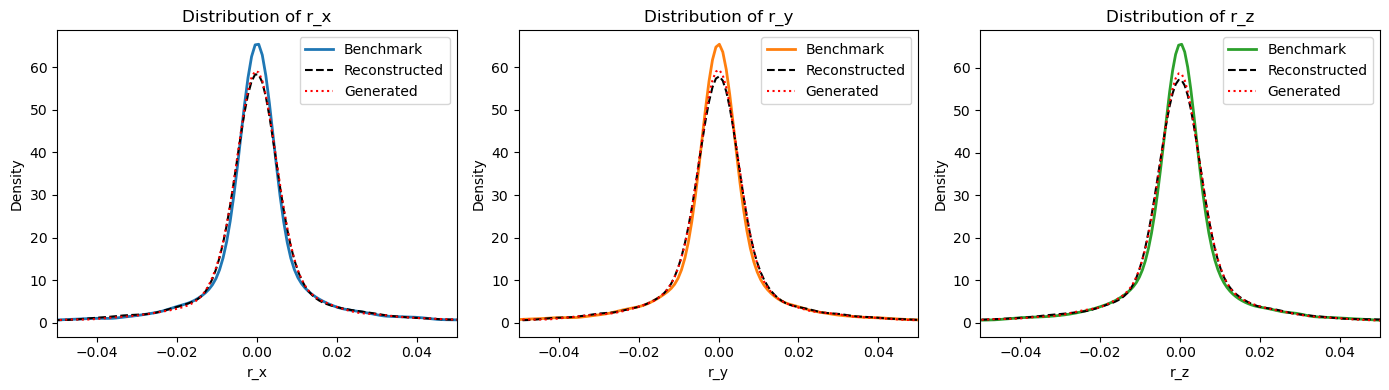

In [94]:
plot_r_distributions(valModel, *val_ts, n_samples=20000, device=device, Tr=1, Tz=1)

In [95]:
def visualize_latent_distributions(model, r_next, c_n, r_next_prev=None, c_prev=None,
                                   n_samples=50000, device="cpu"):
    """
    Visualize latent space distributions for encoder vs conditional AR(1) prior.

    Args:
        model: trained CVAE with attached scalers (scaler_v, scaler_r)
        r_next (np.ndarray): true target r_{n+1}
        c_n (np.ndarray): conditioning variables [v_n, r_n]
        r_next_prev (np.ndarray, optional): previous r_n
        c_prev (np.ndarray, optional): previous conditioning [v_{n-1}, r_{n-1}]
        n_samples: number of samples to analyze
        device: torch device
    """
    model.eval()

    # --- Subsample ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]
    if r_next_prev is not None:
        r_next_prev_s = r_next_prev[idx]
    if c_prev is not None:
        c_prev_s = c_prev[idx]

    # --- Forward pass to get latent distributions ---
    with torch.no_grad():
        if r_next_prev is not None and c_prev is not None:
            is_new_seq = torch.zeros(len(c_s), 1, device=device)
            _, (q_mu, q_logv), _, _ = model(r_next_s, c_s, r_next_prev_s, c_prev_s, is_new_seq)
        else:
            # Simpler (non-AR) pass if prev data not given
            q_mu, q_logv = model.encode(r_next_s, c_s)

        # Always compute prior for comparison
        p_mu, p_logv, rho = model.prior_params(c_s)

    # --- Move to numpy ---
    q_mu, q_logv = q_mu.cpu().numpy(), q_logv.cpu().numpy()
    p_mu, p_logv = p_mu.cpu().numpy(), p_logv.cpu().numpy()

    q_std = np.exp(0.5 * q_logv)
    p_std = np.exp(0.5 * p_logv)
    zdim = q_mu.shape[1]

    # --- Plot histograms ---
    fig, axes = plt.subplots(2, zdim, figsize=(4*zdim, 6))
    for i in range(zdim):
        # Means
        ax = axes[0, i]
        ax.hist(q_mu[:, i], bins=50, alpha=0.6, label="Encoder μ_q", color="tab:blue")
        ax.hist(p_mu[:, i], bins=50, alpha=0.6, label="Prior μ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: means")
        ax.legend()

        # Standard deviations
        ax = axes[1, i]
        ax.hist(q_std[:, i], bins=50, alpha=0.6, label="Encoder σ_q", color="tab:blue")
        ax.hist(p_std[:, i], bins=50, alpha=0.6, label="Prior σ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: stds")
        ax.legend()

    plt.tight_layout()
    plt.show()

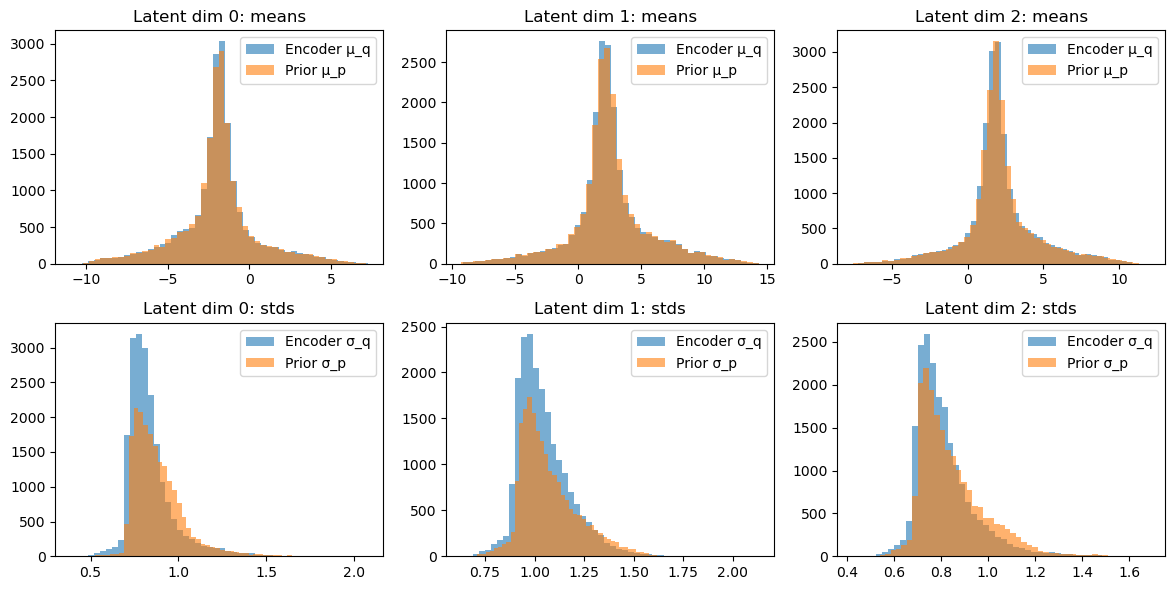

In [96]:
# Assuming you have arrays from benchmark data
# r_n, v_n, r_next -> each [N, 3]
visualize_latent_distributions(valModel, *val_ts, n_samples=20000, device=device)

In [97]:
batch = next(iter(val_loader))
r_nxt_b, c_t, r_prev_b, c_prev_b, is_new_seq_b = [x.to(device) for x in batch]
with torch.no_grad():
    dec_out, (q_mu,q_logv), (p_mu,p_logv), _ = valModel(r_nxt_b, c_t, r_prev_b, c_prev_b, is_new_seq_b)
    q_std = torch.exp(0.5*q_logv).mean().item()
    p_std = torch.exp(0.5*p_logv).mean().item()
    mu_r, log_sig_r, _ = dec_out
    r_std = torch.exp(log_sig_r).mean().item()
print(f"mean q_std={q_std:.3f}  p_std={p_std:.3f}  decoder_sigma={r_std:.3f}")

mean q_std=0.894  p_std=0.931  decoder_sigma=0.443


In [98]:
def stats(x): 
    x = x.detach().cpu().numpy().reshape(-1)
    qs = np.quantile(x, [0.1,0.5,0.9])
    return f"mean={x.mean():.3f} q10={qs[0]:.3f} q50={qs[1]:.3f} q90={qs[2]:.3f}"
print("p_std:", stats(torch.exp(0.5*p_logv)))
print("q_std:", stats(torch.exp(0.5*q_logv)))
print("dec σ:", stats(torch.exp(log_sig_r)))

p_std: mean=0.931 q10=0.736 q50=0.918 q90=1.152
q_std: mean=0.894 q10=0.716 q50=0.866 q90=1.112
dec σ: mean=0.443 q10=0.248 q50=0.311 q90=0.830


In [117]:
random_sample = torch.rand(6)
valModel.reset_latent_state(batch_size=1)
valModel.sample(random_sample)

cuda


array([0.01603616, 0.09499765, 0.06917689], dtype=float32)